In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

In [2]:

X, y=make_moons(n_samples=500, noise=0.05, random_state=42)
df = pd.DataFrame(data=X, columns=["Feature1","Feature2"])
df["Clusters"]=y
print("First 10 rows of the Synthetic Dataset : \n")
print(df)
print("The shape of the dataset : ",df.shape)


First 10 rows of the Synthetic Dataset : 

     Feature1  Feature2  Clusters
0    0.830586 -0.447733         1
1    0.701678  0.816918         0
2    1.022080 -0.492571         1
3   -0.316765  0.953438         0
4    0.293226  1.057185         0
..        ...       ...       ...
495  0.239754  0.985462         0
496  0.072145  0.184834         1
497  0.590273 -0.365577         1
498  1.619465 -0.283658         1
499  0.228960  1.063974         0

[500 rows x 3 columns]
The shape of the dataset :  (500, 3)


In [4]:
scaler = StandardScaler()
X_scaled = df.copy()
X_scaled[["Feature1","Feature2"] ]= scaler.fit_transform(X_scaled[["Feature1","Feature2"]])
print("First five rows of scaled dataset : ")
print(X_scaled)

First five rows of scaled dataset : 
     Feature1  Feature2  Clusters
0    0.375125 -1.403679         1
1    0.226815  1.135628         0
2    0.595442 -1.493710         1
3   -0.944918  1.409748         0
4   -0.243115  1.618062         0
..        ...       ...       ...
495 -0.304636  1.474047         0
496 -0.497472 -0.133542         1
497  0.098642 -1.238718         1
498  1.282741 -1.074231         1
499 -0.317055  1.631692         0

[500 rows x 3 columns]


In [7]:
KMeans_model = KMeans(n_clusters=2,random_state=42,n_init=10)
X_scaled["KMeans_Clusters"] = KMeans_model.fit_predict(X_scaled[["Feature1","Feature2"]])
print("The first five rows of thedataset after KMeans Clustering : ")
print(X_scaled.head(5))

The first five rows of thedataset after KMeans Clustering : 
   Feature1  Feature2  Clusters  KMeans_Clusters
0  0.375125 -1.403679         1                0
1  0.226815  1.135628         0                1
2  0.595442 -1.493710         1                0
3 -0.944918  1.409748         0                1
4 -0.243115  1.618062         0                1


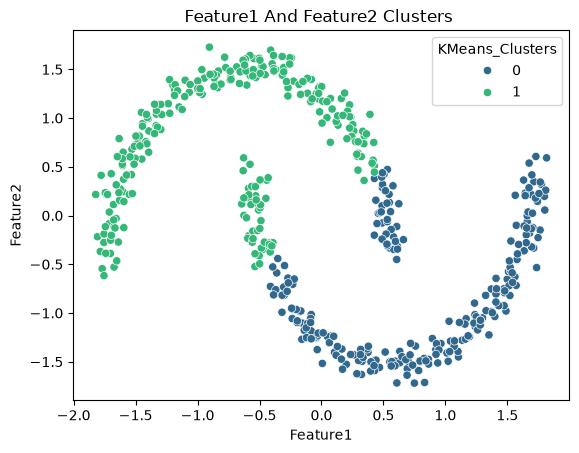

In [8]:
sns.scatterplot(data=X_scaled,x="Feature1", y="Feature2",hue="KMeans_Clusters",markers="o",palette="viridis")
plt.title("Feature1 And Feature2 Clusters ")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

In [10]:
DBSCAN_model =DBSCAN(eps=0.3, min_samples=5)
X_scaled["DBSCAN_Clusters"] = DBSCAN_model.fit_predict(X_scaled[["Feature1","Feature2"]])
print("The first five rows of the dataset after DBSCAN Clustering : ")
print(X_scaled.head(5)) 

The first five rows of the dataset after DBSCAN Clustering : 
   Feature1  Feature2  Clusters  KMeans_Clusters  DBSCAN_Clusters
0  0.375125 -1.403679         1                0                0
1  0.226815  1.135628         0                1                1
2  0.595442 -1.493710         1                0                0
3 -0.944918  1.409748         0                1                1
4 -0.243115  1.618062         0                1                1


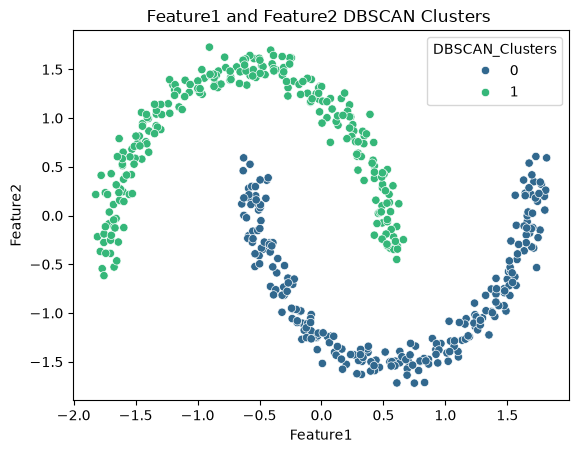

In [11]:
sns.scatterplot(data=X_scaled,x="Feature1", y="Feature2",hue="DBSCAN_Clusters", markers="o",palette="viridis")
plt.title("Feature1 and Feature2 DBSCAN Clusters ")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()